In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from alu import alu_1_bit
from run_circuit import aer_simulator, ibm_fake_simulator, ibm_quantum_hardware

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_quantum_platform' is saved."

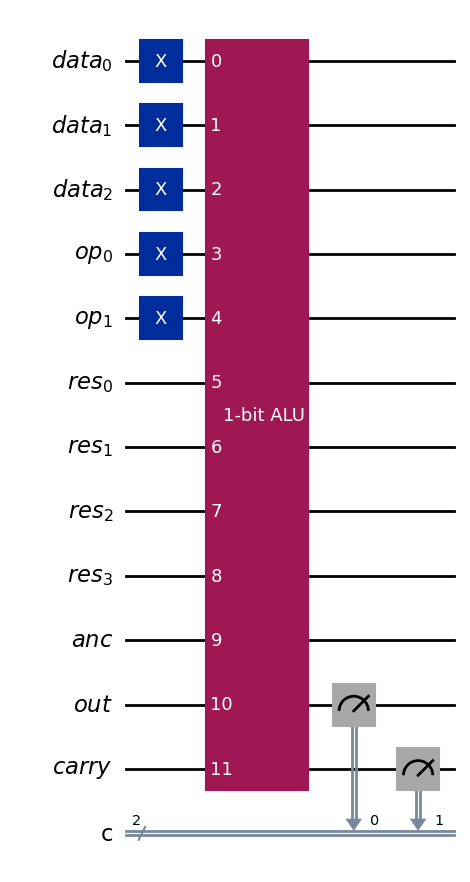

Aer Simulator Measurement Result:  {'11': 1024}
IBM Fake Simulator Measurement Result:  {'11': 717, '10': 259, '01': 30, '00': 18}


TranspilerError: 'Invalid plugin name ibm_dynamic_circuits for stage translation'

In [3]:
data = QuantumRegister(3, "data")
op = QuantumRegister(2, "op")
res = QuantumRegister(4, "res")
anc = QuantumRegister(1, "anc")
out = QuantumRegister(1, "out")
carry = QuantumRegister(1, "carry")
c = ClassicalRegister(2, "c")
qc = QuantumCircuit(data, op, res, anc, out, carry, c)

# Input A, B
qc.x(0)
qc.x(1)
# Carry Cin
qc.x(2)

# Control bits, q0, q1
qc.x(3)
qc.x(4)

qc.append(alu_1_bit().to_gate(), [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
qc.measure([10, 11], [0, 1])
display(qc.draw("mpl"))

aer_simulator(qc, shots=1024)
ibm_fake_simulator(qc, shots=1024)
ibm_quantum_hardware(qc, shots=1024)